# Convex band domains: y1(x) / y2(x) boundaries

`BandDomainOptimizer` (`vizopt.templates.band_vs_band`) is a convex-only counterpart to `StarDomainOptimizer`. Instead of a center + K radii at uniformly-spaced angles, each region is represented by:

- `x_bounds = [x_min, x_max]` — itself an optimization variable
- `upper(x)` / `lower(x)` — sampled at K uniformly-spaced columns between `x_min` and `x_max`

A convex region is exactly the area between a concave upper boundary and a convex lower boundary, so enclosure and exclusion checks reduce to interpolating `upper`/`lower` at a query x and comparing y — no polygon clipping needed. The trade-off: only convex shapes are representable (no concave notches, unlike the star representation).

This notebook builds up from a single band with a target area, to nested bands (enclosure), to overlapping bands pushed apart (exclusion).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import SVG

from vizopt.animation import SnapshotCallback
from vizopt.base import OptimConfig
from vizopt.templates.band_vs_band import BandDomainOptimizer
from vizopt.utils import _SVG_SET_COLORS


def plot_bands(ax, results, title=""):
    """Fill/outline each band's (x, upper) -> (x, lower) polygon."""
    ax.set_title(title, fontsize=10)
    ax.set_aspect("equal")
    ax.axis("off")
    for s, res in enumerate(results):
        color = _SVG_SET_COLORS[s % len(_SVG_SET_COLORS)]
        bx = np.concatenate([res["x"], res["x"][::-1]])
        by = np.concatenate([res["upper"], res["lower"][::-1]])
        ax.fill(bx, by, color=color, alpha=0.25, zorder=1)
        ax.plot(bx, by, color=color, lw=1.5, zorder=2)
        cx = (res["x_min"] + res["x_max"]) / 2
        cy = (res["upper"].mean() + res["lower"].mean()) / 2
        ax.text(cx, cy, f"set {s}", ha="center", va="center", fontsize=8, fontweight="bold")

## A single band with a target area

The simplest case: one convex region, no enclosure or exclusion constraints — just a target area. It starts as a square (the default rectangle initialization) and, since only the perimeter term shapes it beyond that, relaxes toward a rounder, lower-perimeter outline that still hits the target area.

Iteration 0: loss = 9.000000953674316
Iteration 100: loss = 8.77485466003418
Iteration 200: loss = 8.74401569366455
Iteration 300: loss = 8.72807502746582
Iteration 400: loss = 8.721545219421387
Achieved area: 5.969  (target: 6.0)


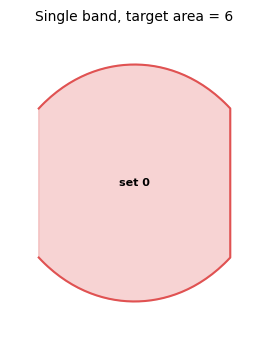

In [2]:
simple = BandDomainOptimizer(
    n_sets=1,
    initial_centers=np.array([[0.0, 0.0]], dtype=np.float32),
    target_areas=[6.0],
    initial_half_width=1.0,
    initial_half_height=1.0,
    weight_perimeter=0.3,
)
simple.optimize(OptimConfig(n_iters=500, learning_rate=2e-2))

result = simple.sets_[0]
area = np.trapezoid(result["upper"] - result["lower"], result["x"])
print(f"Achieved area: {area:.3f}  (target: 6.0)")

fig, ax = plt.subplots(figsize=(4, 4))
plot_bands(ax, simple.sets_, title="Single band, target area = 6")
ax.autoscale_view()
ax.margins(0.15)

## Nested bands: an inner region inside an outer container

Set 0 (small, target area 1) and set 1 (large, target area 8) with `enclosures=[(0, 1)]`: set 0's boundary must stay inside set 1's. This is the band analog of `StarDomainOptimizer`'s enclosure demo.

Iteration 0: loss = 21.181184768676758
Iteration 100: loss = 17.686561584472656
Iteration 200: loss = 16.985074996948242
Iteration 300: loss = 16.533695220947266
Iteration 400: loss = 16.315921783447266


Iteration 500: loss = 16.223264694213867
Set 0: area = 0.952
Set 1: area = 7.966


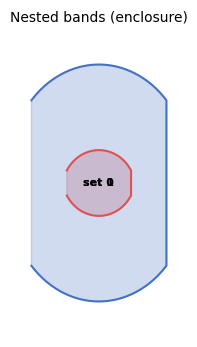

In [3]:
nested_centers = np.array([[0.0, 0.0], [0.0, 0.0]], dtype=np.float32)

nested = BandDomainOptimizer(
    n_sets=2,
    initial_centers=nested_centers,
    target_areas=[1.0, 8.0],
    enclosures=[(0, 1)],
    initial_half_width=0.6,
    weight_enclosure=25.0,
)
cb_nested = SnapshotCallback(every=10)
nested.optimize(OptimConfig(n_iters=600, learning_rate=2e-2), callback=cb_nested)

for s, res in enumerate(nested.sets_):
    area = np.trapezoid(res["upper"] - res["lower"], res["x"])
    print(f"Set {s}: area = {area:.3f}")

fig, ax = plt.subplots(figsize=(4, 4))
plot_bands(ax, nested.sets_, title="Nested bands (enclosure)")
ax.autoscale_view()
ax.margins(0.15)

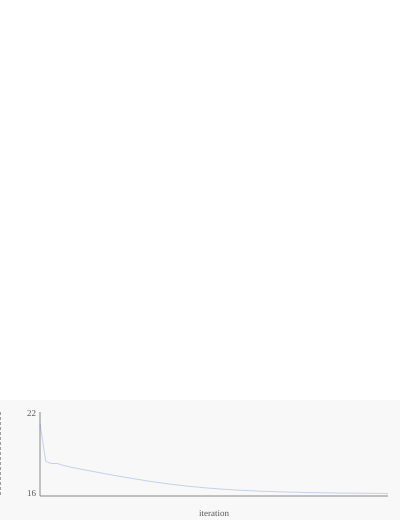

In [4]:
SVG(data=nested.animate_svg(cb_nested, fps=15, size=400))

## Overlapping bands pushed apart: exclusion

Two bands with the same target area, started at overlapping but distinct positions (identical centers would give both sets identical gradients under deterministic gradient descent — they'd move in lockstep forever and never separate). With exclusion enabled they end up side by side.

`weight_convexity` is 0 (disabled) by default — the representation *can* express convex shapes, but nothing forces it to. Left at 0, the exclusion term alone is happy to carve a wavy, non-convex boundary around the other set; turning it on here keeps the boundary convex while still separating.

Iteration 0: loss = 1030.652587890625
Iteration 100: loss = 2262.627685546875
Iteration 200: loss = 1689.9190673828125
Iteration 300: loss = 1021.1964111328125


Iteration 400: loss = 644.9224243164062
Iteration 500: loss = 450.13360595703125
Iteration 600: loss = 388.46881103515625
Iteration 700: loss = 305.49737548828125


Iteration 800: loss = 282.21063232421875
Iteration 900: loss = 289.89154052734375
Iteration 1000: loss = 175.87124633789062
Iteration 1100: loss = 200.34112548828125


Iteration 1200: loss = 186.42820739746094
Iteration 1300: loss = 146.058349609375
Iteration 1400: loss = 127.57301330566406
Iteration 1500: loss = 103.33958435058594


Iteration 1600: loss = 80.78050231933594
Iteration 1700: loss = 63.92138671875
Iteration 1800: loss = 61.93477249145508


Iteration 1900: loss = 56.83596420288086


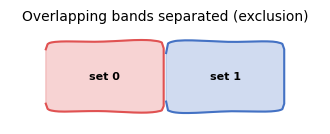

In [5]:
exclusion_centers = np.array([[-0.6, 0.0], [0.6, 0.0]], dtype=np.float32)

excluded = BandDomainOptimizer(
    n_sets=2,
    initial_centers=exclusion_centers,
    target_areas=[3.0, 3.0],
    initial_half_width=1.0,
    weight_exclusion=60.0,
    weight_convexity=2.0,
)
cb_excl = SnapshotCallback(every=30)
excluded.optimize(OptimConfig(n_iters=2000, learning_rate=2e-2), callback=cb_excl)

fig, ax = plt.subplots(figsize=(4, 4))
plot_bands(ax, excluded.sets_, title="Overlapping bands separated (exclusion)")
ax.autoscale_view()
ax.margins(0.15)

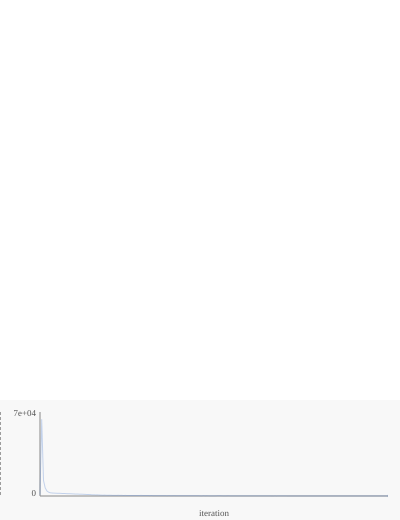

In [6]:
SVG(data=excluded.animate_svg(cb_excl, fps=15, size=400))

## Convex-only trade-off

Because `upper(x)`/`lower(x)` fully determine the shape, this representation can only ever produce convex regions — there's no way to carve a concave notch the way a star-shaped boundary can. In exchange, enclosure/exclusion checks are cheap pointwise comparisons instead of polygon containment tests. See `notebooks/experiments/star_and_star.ipynb` for the star-shaped (non-convex-capable) counterpart, `StarDomainOptimizer`.